# HAI + HAIEnd Dataset Merging

This notebook explains how the two datasets are loaded and merged.

## The two datasets

| Dataset | Files | Columns | Description |
|---|---|---|---|
| **HAI** | `hai-train1..4.csv`, `hai-test1..2.csv` | 87 | Sensor readings from the HAI testbed (P1/P2/P3/P4 subsystems) |
| **HAIEnd** | `end-train1..4.csv`, `end-test1..2.csv` | 226 | Extended sensor readings from the HIEND system (DM-* signals, PLC outputs) |

Both cover the same physical system and the same time windows — they need to be **merged on timestamp**.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HAI_DIR   = 'C:/Users/farah/OneDrive/Desktop/AI_project/hai-23.05'
HIEND_DIR = 'C:/Users/farah/OneDrive/Desktop/AI_project/haiend-23.05'

## Step 1 — Inspect the timestamps

Load a small sample from both `train1` files and compare the first few timestamps.

In [14]:
hai_sample   = pd.read_csv(f'{HAI_DIR}/hai-train1.csv',   nrows=5)
hiend_sample = pd.read_csv(f'{HIEND_DIR}/end-train1.csv', nrows=5)

print('HAI first timestamps:')
print(hai_sample.iloc[:, 0].tolist(), '\n')

print('HAIEnd first timestamps:')
print(hiend_sample.iloc[:, 0].tolist())

hai_sample   = hai_sample.set_index(hai_sample.columns[0])
hiend_sample = hiend_sample.set_index(hiend_sample.columns[0])

display(hai_sample)
display(hiend_sample)


HAI first timestamps:
['2022-08-04 18:00:01', '2022-08-04 18:00:02', '2022-08-04 18:00:03', '2022-08-04 18:00:04', '2022-08-04 18:00:05'] 

HAIEnd first timestamps:
['2022-08-04 18:00:00', '2022-08-04 18:00:01', '2022-08-04 18:00:02', '2022-08-04 18:00:03', '2022-08-04 18:00:04']


,P1_FCV01D,P1_FCV01Z,P1_FCV02D,P1_FCV02Z,P1_FCV03D,P1_FCV03Z,P1_FT01,P1_FT01Z,P1_FT02,P1_FT02Z,...,P4_ST_PS,P4_ST_PT01,P4_ST_TT01,x1001_05_SETPOINT_OUT,x1001_15_ASSIGN_OUT,x1002_07_SETPOINT_OUT,x1002_08_SETPOINT_OUT,x1003_10_SETPOINT_OUT,x1003_18_SETPOINT_OUT,x1003_24_SUM_OUT
timestamp,,,,,,,,,,,,,,,,,,,,,
2022-08-04 18:00:01,72.15386,72.59521,15,12.44507,52.55638,53.76587,54.96975,293.16074,2460.51758,3162.22290,...,7.00589,10020,27084,0.19579,1.10768,342.67529,981.62262,3162.22290,28,31.53963
2022-08-04 18:00:02,72.13303,72.59521,15,12.44507,52.51562,53.76587,55.16052,286.20914,2453.65161,3164.09961,...,7.00589,10022,27085,0.19579,1.11615,342.67529,981.62262,3164.09961,28,31.56786
2022-08-04 18:00:03,72.21181,72.59521,15,12.43744,52.50791,53.76587,54.96975,287.20242,2454.03271,3159.59546,...,7.00589,10000,27090,0.19579,1.12107,342.67529,981.62262,3159.59546,28,31.58426
2022-08-04 18:00:04,72.21734,72.59521,15,12.44507,52.50019,53.76587,54.77904,286.20914,2450.59961,3159.84546,...,7.00589,9998,27092,0.19579,1.12748,342.67529,981.62262,3159.84546,28,31.60562
2022-08-04 18:00:05,72.26208,72.59521,15,12.43744,52.54727,53.76587,55.16052,285.21619,2456.70312,3157.59326,...,7.00589,9996,27092,0.19579,1.13720,342.67529,981.62262,3157.59326,28,31.63805


,DM-PP01-R,DM-FT01Z,DM-FT02Z,DM-FT03Z,1001.2-OUT,1001.7-OUT1,1001.7-OUT2,1001.8-OUT,1002.2-OUT,1002.6-OUT,...,DM-PCV01-D,DM-PCV01-Z,DM-PCV02-D,DM-PCV02-Z,DM-PIT01,DM-PIT02,DM-PWIT-03,DM-TIT01,DM-TIT02,DM-TWIT-03
Timestamp,,,,,,,,,,,,,,,,,,,,,
2022-08-04 18:00:00,0,287.202423,3166.977539,983.985901,0,0,0,0,0,0,...,27.862734,28.642271,12,11.819457,1.260528,0.375519,0.000585,30.187988,35.208130,27.224792
2022-08-04 18:00:01,0,293.160736,3162.222900,982.681396,0,0,0,0,0,0,...,27.824905,28.306576,12,11.819457,1.249084,0.376282,0.000585,30.187988,35.192867,27.224792
2022-08-04 18:00:02,0,286.209137,3164.099609,983.550964,0,0,0,0,0,0,...,27.853020,28.283689,12,11.819457,1.242981,0.376282,0.000585,30.187988,35.177608,27.224792
2022-08-04 18:00:03,0,287.202423,3159.595459,983.550964,0,0,0,0,0,0,...,27.844429,28.298950,12,11.819457,1.239166,0.376282,0.000585,30.203249,35.192867,27.224792
2022-08-04 18:00:04,0,286.209137,3159.845459,983.550964,0,0,0,0,0,0,...,27.837145,28.268433,12,11.819457,1.237640,0.375519,0.000585,30.187988,35.177608,27.224792


### The 1-second offset

HAIEnd starts at `18:00:00` while HAI starts at `18:00:01` — a **consistent 1-second recording lag** in HAIEnd across all files.

**Strategy: inner join on exact timestamp.**  
The unmatched boundary row (the very first HAIEnd row with no HAI counterpart) is simply dropped — no values are manipulated or shifted.

In [15]:
# Verify offset is consistent across all train files
results = []
for i in range(1, 5):
    hai   = pd.read_csv(f'{HAI_DIR}/hai-train{i}.csv',   nrows=3)
    hiend = pd.read_csv(f'{HIEND_DIR}/end-train{i}.csv', nrows=3)
    h_ts = pd.to_datetime(hai.iloc[:, 0])
    e_ts = pd.to_datetime(hiend.iloc[:, 0])
    offset = (e_ts - h_ts).dt.total_seconds().iloc[0]
    n_hai   = len(pd.read_csv(f'{HAI_DIR}/hai-train{i}.csv'))
    n_hiend = len(pd.read_csv(f'{HIEND_DIR}/end-train{i}.csv'))
    results.append({'file': f'train{i}', 'offset_sec': offset,
                    'HAI rows': n_hai, 'HAIEnd rows': n_hiend})

pd.DataFrame(results).set_index('file')

,offset_sec,HAI rows,HAIEnd rows
file,,,
train1,-1.0,280800,280800
train2,-1.0,291600,291600
train3,-1.0,126000,126000
train4,-1.0,198000,198000


## Step 2 — Duplicate columns

35 columns exist in **both** datasets under different names (documented in the HAIEnd dataset paper).  
**HAIEnd names take priority** — the HAI versions are dropped before merging.

In [16]:
HAI_DUPLICATES = [
    'P1_B2016',    # 1001.15-OUT
    'P1_FCV01D',   # DM-FCV01-D
    'P1_FCV01Z',   # DM-FCV01-Z
    'P1_FCV02D',   # DM-FCV02-D
    'P1_FCV02Z',   # DM-FCV02-Z
    'P1_FCV03D',   # DM-FCV03-D
    'P1_FCV03Z',   # DM-FCV03-Z
    'P1_FT01',     # DM-FT01
    'P1_FT01Z',    # DM-FT01Z
    'P1_FT02',     # DM-FT02
    'P1_FT02Z',    # DM-FT02Z
    'P1_FT03',     # DM-FT03
    'P1_FT03Z',    # DM-FT03Z
    'P1_LCV01D',   # DM-LCV01-D
    'P1_LCV01Z',   # DM-LCV01-Z
    'P1_LIT01',    # DM-LIT01
    'P1_PCV01D',   # DM-PCV01-D
    'P1_PCV01Z',   # DM-PCV01-Z
    'P1_PCV02D',   # DM-PCV02-D
    'P1_PCV02Z',   # DM-PCV02-Z
    'P1_PIT01_HH', # DM-PIT01-HH
    'P1_PIT01',    # DM-PIT01
    'P1_PIT02',    # DM-PIT02
    'P1_PP01AD',   # DM-PP01A-D
    'P1_PP01AR',   # DM-PP01A-R
    'P1_PP01BD',   # DM-PP01B-D
    'P1_PP01BR',   # DM-PP01B-R
    'P1_PP02D',    # DM-PP02-D
    'P1_PP02R',    # DM-PP02-R
    'P1_SOL01D',   # DM-SOL01-D
    'P1_SOL03D',   # DM-SOL03-D
    'P1_STSP',     # DM-ST-SP
    'P1_TIT01',    # DM-TIT01
    'P1_TIT03',    # DM-TIT02  (HAI TIT03 = HAIEnd TIT02 — naming inconsistency in source data)
    'P4_ST_GOV',   # GATEOPEN
]

print(f'{len(HAI_DUPLICATES)} HAI columns will be dropped in favour of their HAIEnd counterparts')

35 HAI columns will be dropped in favour of their HAIEnd counterparts


## Step 3 — Merge function

In [17]:
import os

def load_merged(split: str, num: int) -> pd.DataFrame:
    hai   = pd.read_csv(os.path.join(HAI_DIR,   f'hai-{split}{num}.csv'))
    hiend = pd.read_csv(os.path.join(HIEND_DIR, f'end-{split}{num}.csv'))

    hai.rename(columns={hai.columns[0]: 'timestamp'}, inplace=True)
    hiend.rename(columns={hiend.columns[0]: 'timestamp'}, inplace=True)

    hai['timestamp']   = pd.to_datetime(hai['timestamp'])
    hiend['timestamp'] = pd.to_datetime(hiend['timestamp'])

    cols_to_drop = [c for c in HAI_DUPLICATES if c in hai.columns]
    hai = hai.drop(columns=cols_to_drop)

    merged = pd.merge(hai, hiend, on='timestamp', how='inner', suffixes=('', '_hiend'))
    return merged

## Step 4 — Load all files and summarise

In [18]:
train_data = {f'train{i}': load_merged('train', i) for i in range(1, 5)}
test_data  = {f'test{i}':  load_merged('test',  i) for i in range(1, 3)}

summary = []
for name, df in {**train_data, **test_data}.items():
    summary.append({'split': name, 'rows': len(df), 'columns': len(df.columns),
                    'start': df['timestamp'].iloc[0], 'end': df['timestamp'].iloc[-1]})

pd.DataFrame(summary).set_index('split')

,rows,columns,start,end
split,,,,
train1,280799,278,2022-08-04 18:00:01,2022-08-07 23:59:59
train2,291599,278,2022-08-13 07:00:01,2022-08-16 15:59:59
train3,125999,278,2022-08-19 16:00:01,2022-08-21 02:59:59
train4,197999,278,2022-08-22 17:00:01,2022-08-24 23:59:59
test1,53999,278,2022-08-12 16:00:01,2022-08-13 06:59:59
test2,230399,278,2022-08-17 00:00:01,2022-08-19 15:59:59


## Plot 1 — Timeline of all splits

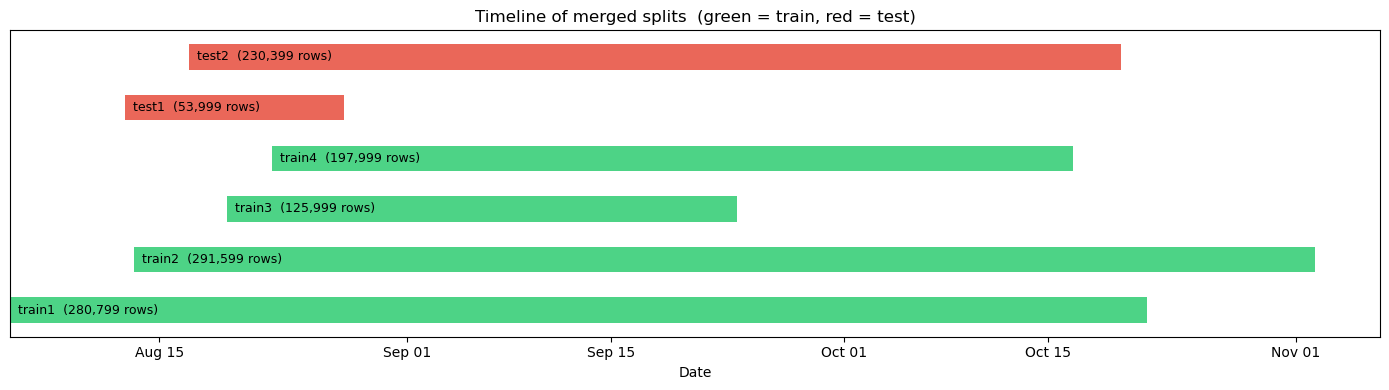

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))

all_splits = {**train_data, **test_data}
colors = {'train': '#2ecc71', 'test': '#e74c3c'}

for i, (name, df) in enumerate(all_splits.items()):
    kind  = 'train' if 'train' in name else 'test'
    start = df['timestamp'].iloc[0]
    end   = df['timestamp'].iloc[-1]
    ax.barh(i, (end - start).total_seconds() / 3600, left=mdates.date2num(start),
            height=0.5, color=colors[kind], alpha=0.85)
    ax.text(mdates.date2num(start), i, f'  {name}  ({len(df):,} rows)', va='center', fontsize=9)

ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.set_xlabel('Date')
ax.set_yticks([])
ax.set_title('Timeline of merged splits  (green = train, red = test)')
plt.tight_layout()
plt.show()

## Plot 2 — Column composition after deduplication

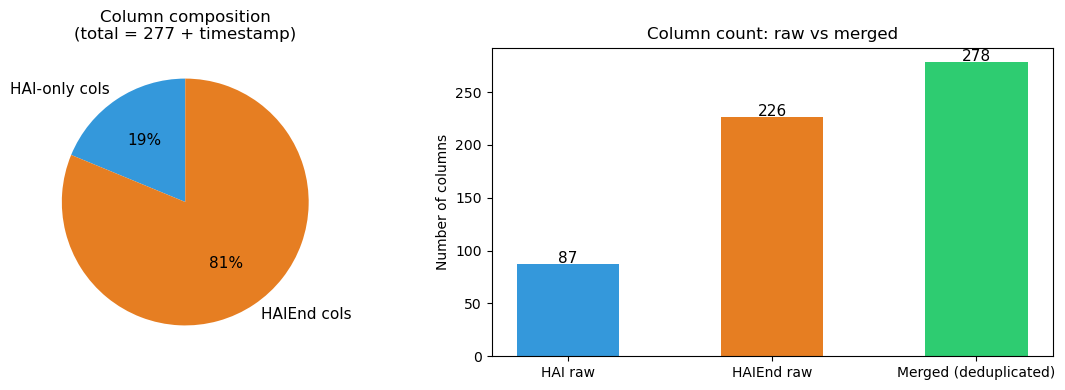

In [20]:
hai_only_cols   = [c for c in train_data['train1'].columns
                   if c.startswith(('P1_','P2_','P3_','P4_','x')) and c != 'timestamp']
hiend_only_cols = [c for c in train_data['train1'].columns
                   if not c.startswith(('P1_','P2_','P3_','P4_','x')) and c != 'timestamp']

labels = ['HAI-only cols', 'HAIEnd cols']
sizes  = [len(hai_only_cols), len(hiend_only_cols)]
colors_pie = ['#3498db', '#e67e22']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(sizes, labels=labels, colors=colors_pie, autopct='%1.0f%%',
            startangle=90, textprops={'fontsize': 11})
axes[0].set_title(f'Column composition\n(total = {sum(sizes)} + timestamp)')

axes[1].bar(['HAI raw', 'HAIEnd raw', 'Merged (deduplicated)'],
            [87, 226, len(train_data['train1'].columns)],
            color=['#3498db', '#e67e22', '#2ecc71'], width=0.5)
axes[1].set_ylabel('Number of columns')
axes[1].set_title('Column count: raw vs merged')
for i, v in enumerate([87, 226, len(train_data['train1'].columns)]):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## Plot 3 — Sample sensors: HAI vs HAIEnd readings for a duplicate pair

To confirm the deduplication was correct, compare a HAI sensor against its HAIEnd counterpart on a short window **before** dropping the HAI column.

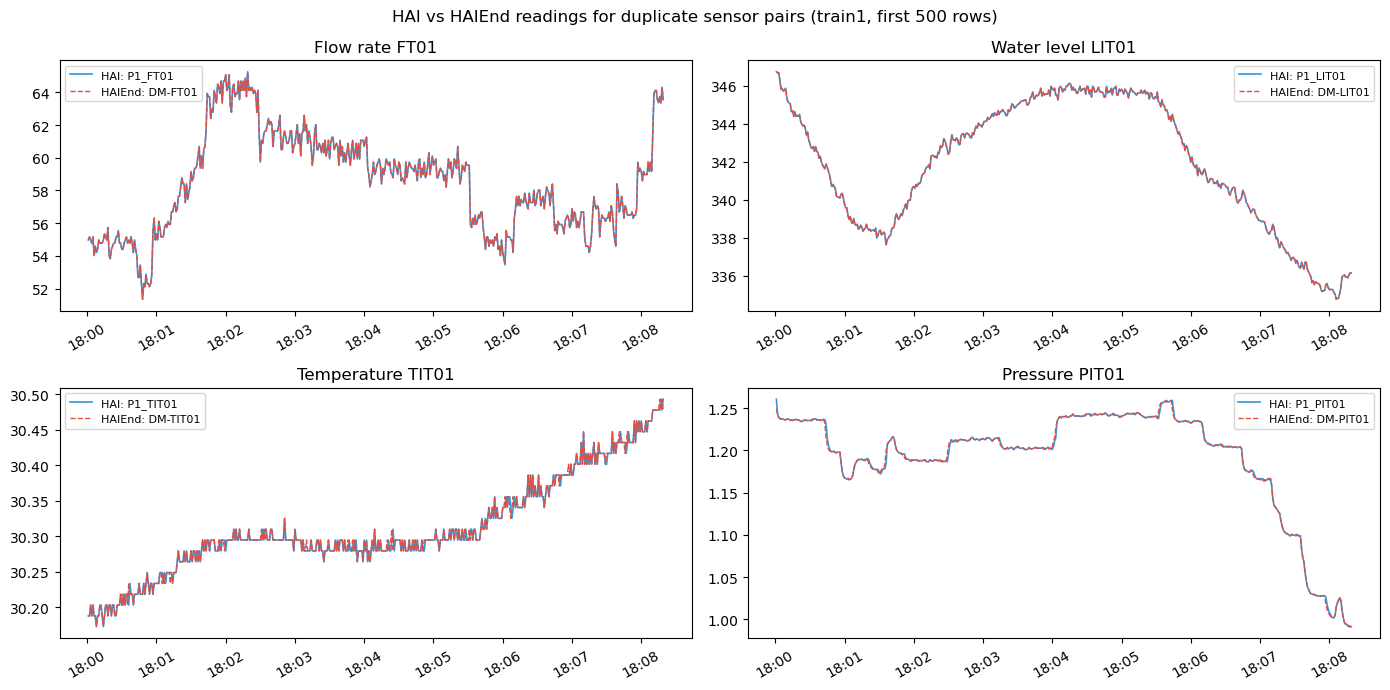

In [21]:
# Load train1 WITHOUT dropping duplicates to show the comparison
hai_raw   = pd.read_csv(f'{HAI_DIR}/hai-train1.csv',   nrows=500)
hiend_raw = pd.read_csv(f'{HIEND_DIR}/end-train1.csv', nrows=500)
hai_raw.rename(columns={hai_raw.columns[0]: 'timestamp'}, inplace=True)
hiend_raw.rename(columns={hiend_raw.columns[0]: 'timestamp'}, inplace=True)
hai_raw['timestamp']   = pd.to_datetime(hai_raw['timestamp'])
hiend_raw['timestamp'] = pd.to_datetime(hiend_raw['timestamp'])
raw_merged = pd.merge(hai_raw, hiend_raw, on='timestamp', how='inner', suffixes=('', '_hiend'))

pairs_to_plot = [
    ('P1_FT01',  'DM-FT01',   'Flow rate FT01'),
    ('P1_LIT01', 'DM-LIT01',  'Water level LIT01'),
    ('P1_TIT01', 'DM-TIT01',  'Temperature TIT01'),
    ('P1_PIT01', 'DM-PIT01',  'Pressure PIT01'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, (hai_col, hiend_col, title) in zip(axes.flat, pairs_to_plot):
    ax.plot(raw_merged['timestamp'], raw_merged[hai_col],
            label=f'HAI: {hai_col}', color='#3498db', linewidth=1.2)
    ax.plot(raw_merged['timestamp'], raw_merged[hiend_col],
            label=f'HAIEnd: {hiend_col}', color='#e74c3c', linewidth=1, linestyle='--')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

fig.suptitle('HAI vs HAIEnd readings for duplicate sensor pairs (train1, first 500 rows)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Plot 4 — Missing rows after inner join

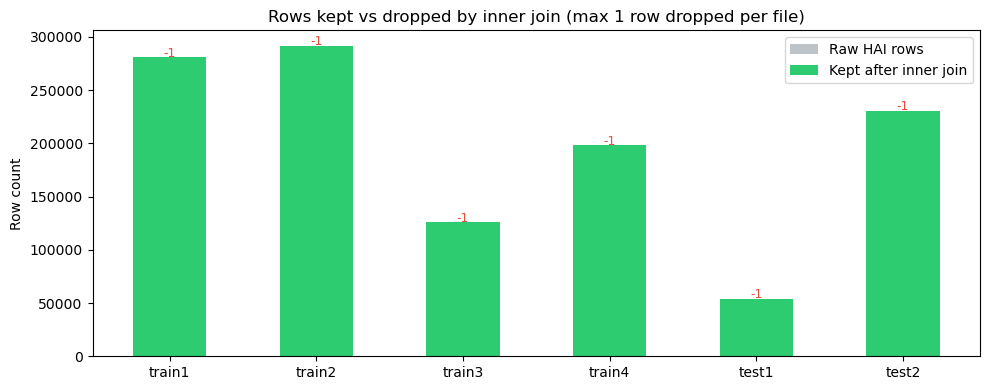

In [ ]:
splits     = list(all_splits.keys())
raw_map = {
    'train1':280800, 'train2':291600, 'train3':126000, 'train4':198000,
    'test1':54000, 'test2':230400
}
raw_counts = [raw_map[s] for s in splits]
merged_counts = [len(all_splits[s]) for s in splits]
dropped = [r - m for r, m in zip(raw_counts, merged_counts)]

x = range(len(splits))
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(x, raw_counts, color='#bdc3c7', label='Raw HAI rows', width=0.5)
ax.bar(x, merged_counts, color='#2ecc71', label='Kept after inner join', width=0.5)
ax.set_xticks(list(x))
ax.set_xticklabels(splits)
ax.set_ylabel('Row count')
ax.set_title('Rows kept vs dropped by inner join (max 1 row dropped per file)')
ax.legend()
for i, d in enumerate(dropped):
    ax.text(i, raw_counts[i] + 500, f'-{d}', ha='center', fontsize=9, color='#e74c3c')
plt.tight_layout()
plt.show()